Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1388700635006519..1.0954489573127413].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.024487975409939057..1.0439037279798622].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0599755985469466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0737391969013363].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.070961500343876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0278888440396863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [

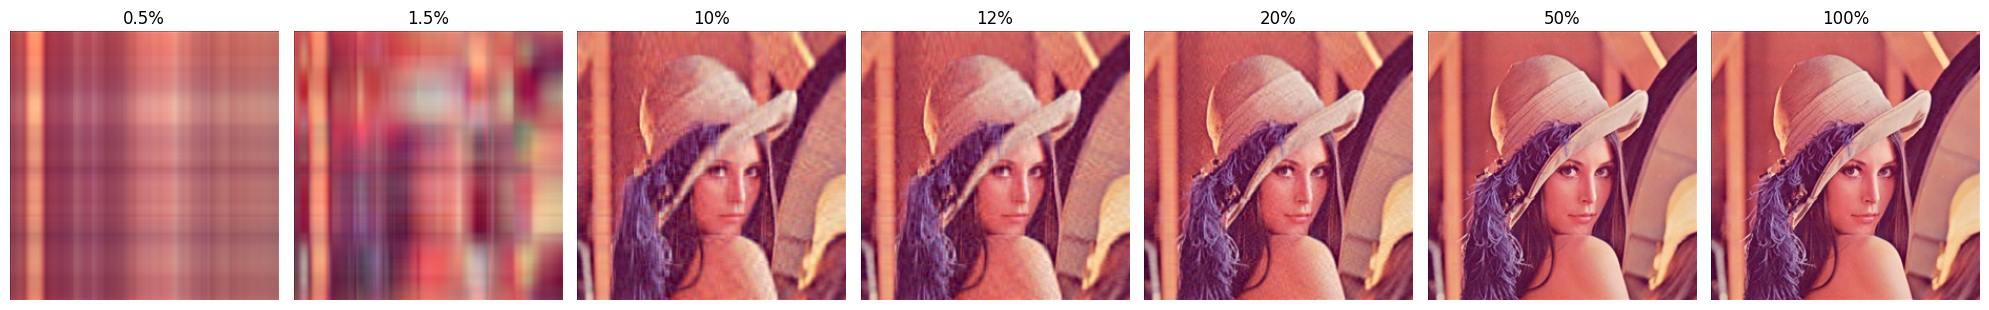

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 检查图像文件是否存在
if os.path.exists('lena.png'):
    # 读取图像
    image = plt.imread('lena.png')
    # 分离颜色通道
    image_a = image[:, :, 0]
    image_b = image[:, :, 1]
    image_c = image[:, :, 2]

    def svd_image(data, percentage):
        U, s, Vt = np.linalg.svd(data)
        num_singular_values = len(s)
        # 根据百分比计算使用的奇异值数量
        k = int(num_singular_values * percentage / 100)
        Sigma = np.zeros(data.shape)
        Sigma[:len(s), :len(s)] = np.diag(s)
        image2 = np.dot(U[:, :k], Sigma[:k, :k]).dot(Vt[:k, :])
        image2[image2 < 0] = 0
        image2[image2 > 255] = 255
        return image2

    percentages = (0.5, 1.5, 10, 12, 20, 50, 100)
    num_images = len(percentages)

    # 创建一个包含多个子图的图形
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))

    for i, percentage in enumerate(percentages):
        # 对每个颜色通道进行 SVD 处理
        A = svd_image(image_a, percentage)
        B = svd_image(image_b, percentage)
        C = svd_image(image_c, percentage)

        # 合并颜色通道
        Image = np.stack((A, B, C), 2)

        # 在对应的子图中显示图像
        axes[i].imshow(Image)
        axes[i].axis('off')
        axes[i].set_title(f'{percentage}%')

    plt.tight_layout()
    plt.show()
else:
    print("图像文件 'lena.png' 不存在。")


In [111]:
import numpy as np

X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([20, 45, 60, 75, 90]).reshape(-1, 1)
X_mean = np.mean(X)
Y_mean = np.mean(Y)
numerator = np.sum((X - X_mean) * (Y - Y_mean))
n = len(X)
covariance = numerator / n


In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 定义数据
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([20, 45, 60, 75, 90]).reshape(-1, 1)

# 创建线性回归模型
model = LinearRegression()

# 拟合模型
m = model.fit(X, Y)

# 获取斜率
slope = model.coef_[0][0]

print("斜率:", slope)

斜率: 1.7


In [23]:
import pandas as pd

data = pd.read_csv('./data/train_u6lujuX_CVtuZ9i.csv')
data


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
